# Deploying a trained RL policy in Xopt: inverted pendulum

This notebook shows how to use a **reinforcement-learning policy trained externally**
(with [stable-baselines3](https://stable-baselines3.readthedocs.io/)) inside Xopt via
`RLGenerator`, which steps a gymnasium environment through `GymEvaluator`.

Xopt does not train or update the policy here -- it is frozen at deployment time.
Training happens once, outside of Xopt (see `train_policy` below, or run
[`inverted_pendulum.py`](inverted_pendulum.py) directly), and the resulting policy is
simply used for inference by `RLGenerator.generate()`.

Requires the optional `rl` extra: `pip install xopt[rl]`.


## Setup and imports


In [1]:
from pathlib import Path
import os

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation
from stable_baselines3 import SAC

from gest_api.vocs import VOCS
from xopt import Xopt
from xopt.evaluator import GymEvaluator
from xopt.generators.rl_generator import RLGenerator
from xopt.vocs import ContextualVariable

MODEL_PATH = Path("sac_pendulum.zip")
ACTION_NAMES = ["torque"]
OBSERVATION_NAMES = ["cos_theta", "sin_theta", "theta_dot"]

## Train (or load) the policy -- entirely outside of Xopt

If `sac_pendulum.zip` already exists (e.g. from running `inverted_pendulum.py`), it is
loaded directly; otherwise a SAC policy is trained here for a modest number of timesteps.


In [2]:
SMOKE_TEST = os.environ.get("SMOKE_TEST")

if MODEL_PATH.exists():
    policy = SAC.load(MODEL_PATH)
else:
    n_timesteps = 2 if SMOKE_TEST else 20_000
    train_env = gym.make("Pendulum-v1")
    policy = SAC("MlpPolicy", train_env, verbose=0)
    policy.learn(total_timesteps=n_timesteps)
    policy.save(MODEL_PATH)
    train_env.close()

policy

/home/rroussel/miniforge3/envs/xopt-dev/lib/python3.13/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Configure Xopt: VOCS, GymEvaluator, RLGenerator

- `torque` is the action variable the policy controls.
- `cos_theta`, `sin_theta`, `theta_dot` are `ContextualVariable`s: contextual inputs to
  the policy that Xopt does not optimize over.
- `reward` is logged as the objective for bookkeeping/plotting only -- the frozen policy,
  not this objective, decides the next action.

The environment is created with `render_mode="rgb_array"` so we can grab frames for the
animation below. We also override the random reset with a non-ideal (but easily
recoverable) starting angle, so the rollout below first shows a quick recovery before
the later perturbation.


In [4]:
vocs = VOCS(
    variables={
        "torque": [-2.0, 2.0],
        "cos_theta": ContextualVariable(),
        "sin_theta": ContextualVariable(),
        "theta_dot": ContextualVariable(),
    },
    objectives={"reward": "MAXIMIZE"},
)

env = gym.make("Pendulum-v1", render_mode="rgb_array")
evaluator = GymEvaluator(
    env=env,
    action_space_names=ACTION_NAMES,
    observation_space_names=OBSERVATION_NAMES,
    max_workers=1,
)

# start well off-vertical (but not a full hang-down swing-up) so recovery is quick
INITIAL_THETA = 2.0
INITIAL_THETA_DOT = 0.0
env.unwrapped.state = np.array([INITIAL_THETA, INITIAL_THETA_DOT])
evaluator._current_observation = np.array(
    [np.cos(INITIAL_THETA), np.sin(INITIAL_THETA), INITIAL_THETA_DOT]
)

generator = RLGenerator(
    vocs=vocs,
    policy=policy,
    action_space_names=ACTION_NAMES,
    observation_space_names=OBSERVATION_NAMES,
    initial_observation=evaluator.current_observation,
)

X = Xopt(generator=generator, evaluator=evaluator)
X


            Xopt
________________________________
Version: 3.1.2.dev8+g78579d2fc.d20260629
Data size: 0
Config as YAML:
data_dump_file: null
evaluator:
  action_history: []
  action_mode: delta
  action_space_names:
  - torque
  env: gymnasium.wrappers.common.TimeLimit
  function: xopt.evaluator.GymEvaluator._evaluate_function
  function_kwargs: {}
  max_workers: 1
  observation_space_names:
  - cos_theta
  - sin_theta
  - theta_dot
  vectorized: false
generator:
  action_space_names:
  - torque
  deterministic: true
  initial_observation:
    cos_theta: -0.4161468365471424
    sin_theta: 0.9092974268256817
    theta_dot: 0.0
  name: rl_policy
  observation_space_names:
  - cos_theta
  - sin_theta
  - theta_dot
  policy: stable_baselines3.sac.sac.SAC
  returns_id: false
  supports_batch_generation: false
  supports_constraints: false
  supports_contextual_variables: true
  supports_discrete_variables: false
  supports_multi_objective: false
  supports_single_objective: true
  vocs:
  

## Run the trained agent on the pendulum

Step Xopt forward for one episode, capturing a render frame after every step for the
animation below. Halfway through, we manually kick the pendulum's angular velocity to
simulate an external disturbance and check that the frozen policy recovers.


In [5]:
N_STEPS = 200
PERTURBATION_STEP = N_STEPS // 2
PERTURBATION_THETA_DOT = 8.0

frames = [env.render()]
for step in range(N_STEPS):
    X.step()
    if step == PERTURBATION_STEP:
        # simulate an external disturbance: kick the angular velocity mid-flight
        theta, theta_dot = env.unwrapped.state
        env.unwrapped.state = np.array([theta, theta_dot + PERTURBATION_THETA_DOT])
    frames.append(env.render())

env.close()
X.data.tail()

/home/rroussel/miniforge3/envs/xopt-dev/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


,torque,reward,terminated,truncated,info,cos_theta,sin_theta,theta_dot,next_cos_theta,next_sin_theta,next_theta_dot,xopt_runtime,xopt_error
195,0.811645,-13.395098,False,False,{},-0.879068,0.476696,8.000000,-0.995310,0.096741,8.000000,0.000064,False
196,0.836323,-15.670899,False,False,{},-0.995310,0.096741,8.000000,-0.954414,-0.298488,8.000000,0.000058,False
197,0.831927,-14.457690,False,False,{},-0.954414,-0.298488,8.000000,-0.766030,-0.642805,7.900923,0.000056,False
198,0.792272,-12.213481,False,False,{},-0.766030,-0.642805,7.900923,-0.475700,-0.879608,7.537661,0.000063,False
199,0.720002,-9.952805,False,True,{},-0.475700,-0.879608,7.537661,-0.145939,-0.989294,6.985955,0.000078,False


## Visualize the state trajectory and reward

The dashed line marks the mid-rollout disturbance; the policy was never trained on this
exact perturbation, so recovery afterward demonstrates its robustness.


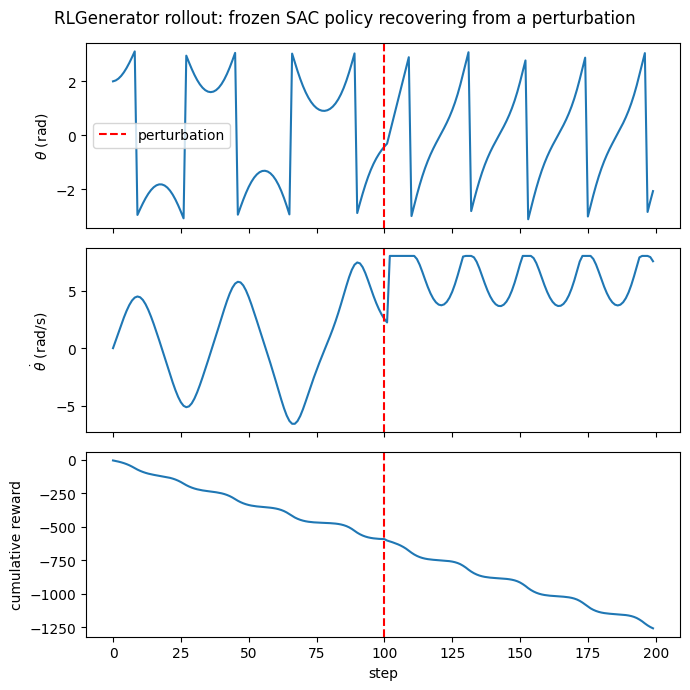

In [6]:
data = X.data.reset_index(drop=True)
theta = np.arctan2(data["sin_theta"], data["cos_theta"])

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

axes[0].plot(theta)
axes[0].set_ylabel(r"$\theta$ (rad)")

axes[1].plot(data["theta_dot"])
axes[1].set_ylabel(r"$\dot{\theta}$ (rad/s)")

axes[2].plot(data["reward"].cumsum())
axes[2].set_ylabel("cumulative reward")
axes[2].set_xlabel("step")

for ax in axes:
    ax.axvline(PERTURBATION_STEP, color="red", linestyle="--", label="perturbation")
axes[0].legend()

fig.suptitle("RLGenerator rollout: frozen SAC policy recovering from a perturbation")
fig.tight_layout()

## Animate the pendulum swing-up inline

Renders the captured `rgb_array` frames as an inline JS animation (`to_jshtml`, no
`ffmpeg` required).


In [7]:
fig_anim, ax_anim = plt.subplots(figsize=(4, 4))
ax_anim.axis("off")
im = ax_anim.imshow(frames[0])


def _update(frame):
    im.set_data(frame)
    return (im,)


ani = animation.FuncAnimation(fig_anim, _update, frames=frames, interval=50, blit=True)
plt.close(fig_anim)
HTML(ani.to_jshtml())